In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('visualization').getOrCreate()

In [2]:
from pyspark.sql.functions import col
appointments_data = [
(1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
(1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
(1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
(1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
(1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
(1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
(1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
(1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
(1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
(1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
(1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
(1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
(1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
(1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
(1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]
columns = [
"appointment_id",
"city",
"department",
"hospital",
"consultation_fee",
"status"
]
df = spark.createDataFrame(appointments_data, columns)
display(df)

DataFrame[appointment_id: bigint, city: string, department: string, hospital: string, consultation_fee: bigint, status: string]

In [5]:
from pyspark.sql.functions import *
import matplotlib.pyplot as plt

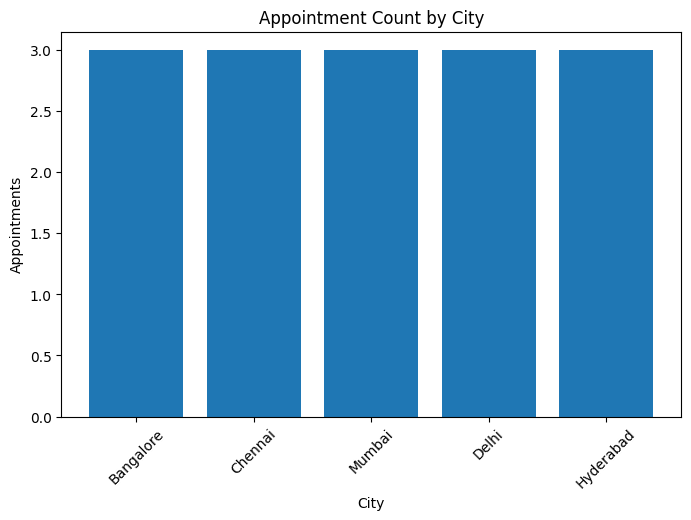

In [6]:
city_count = df.groupBy("city").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_count["city"], city_count["count"])
plt.title("Appointment Count by City")
plt.xlabel("City")
plt.ylabel("Appointments")
plt.xticks(rotation=45)
plt.show()

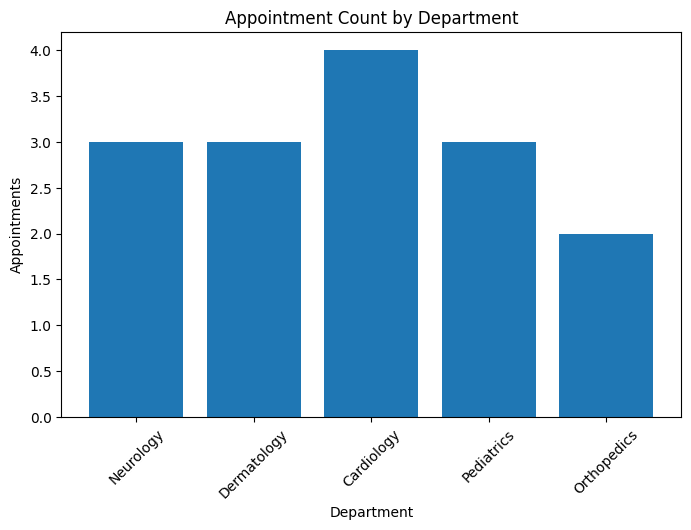

In [7]:
dept_count = df.groupBy("department").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_count["department"], dept_count["count"])
plt.title("Appointment Count by Department")
plt.xlabel("Department")
plt.ylabel("Appointments")
plt.xticks(rotation=45)
plt.show()

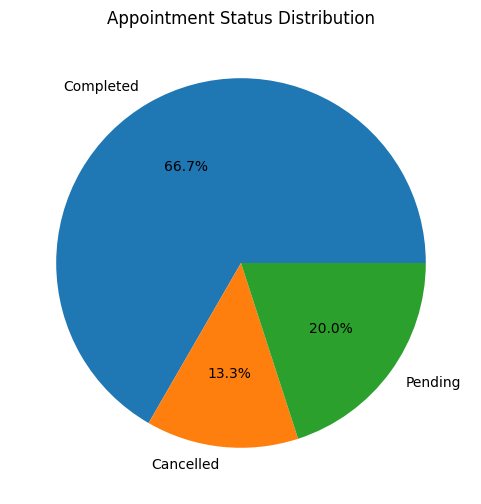

In [8]:
status_count = df.groupBy("status").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    status_count["count"],
    labels=status_count["status"],
    autopct="%1.1f%%"
)
plt.title("Appointment Status Distribution")
plt.show()

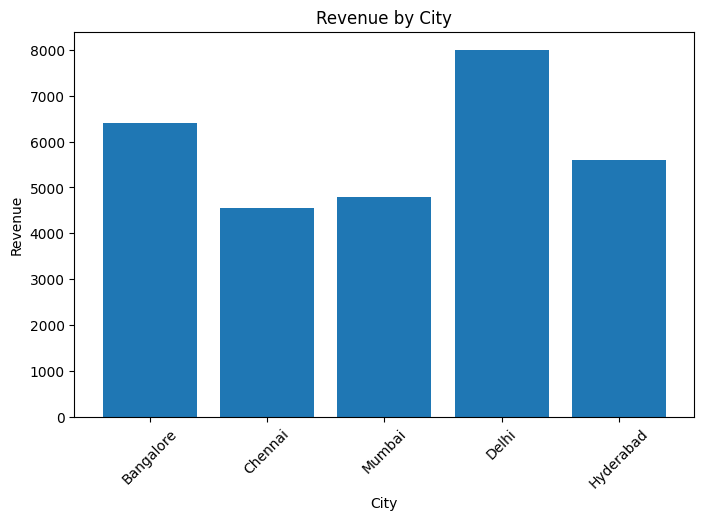

In [9]:
city_revenue = df.groupBy("city") \
    .agg(sum("consultation_fee").alias("revenue")) \
    .toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_revenue["city"], city_revenue["revenue"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

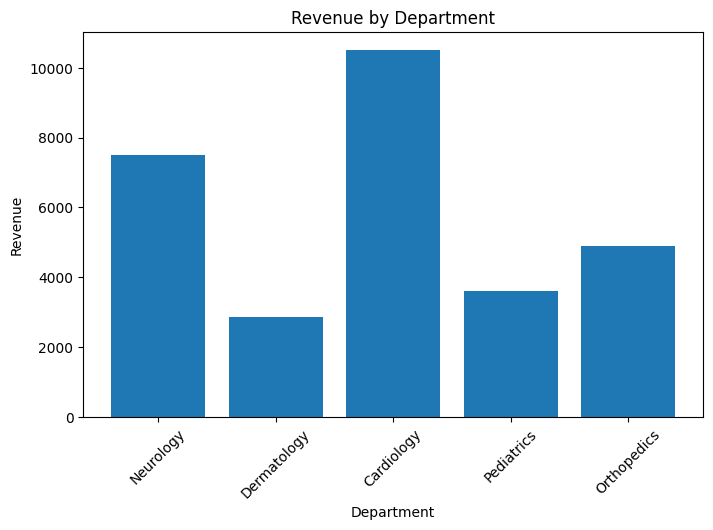

In [10]:
dept_revenue = df.groupBy("department") \
    .agg(sum("consultation_fee").alias("revenue")) \
    .toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_revenue["department"], dept_revenue["revenue"])
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

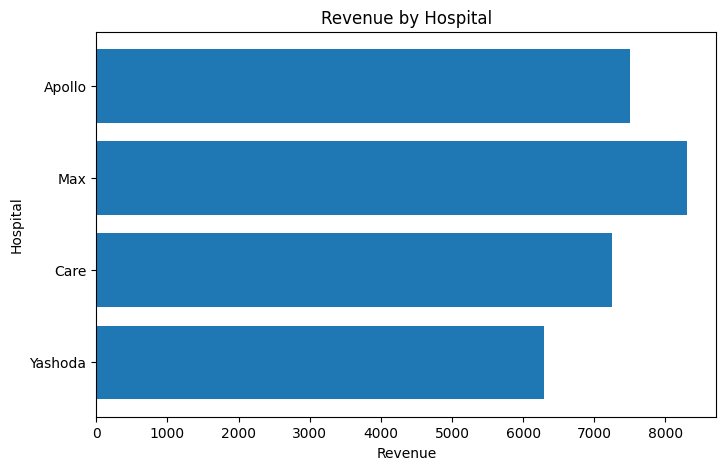

In [11]:
hospital_revenue = df.groupBy("hospital") \
    .agg(sum("consultation_fee").alias("revenue")) \
    .toPandas()

plt.figure(figsize=(8,5))
plt.barh(hospital_revenue["hospital"], hospital_revenue["revenue"])
plt.title("Revenue by Hospital")
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.show()


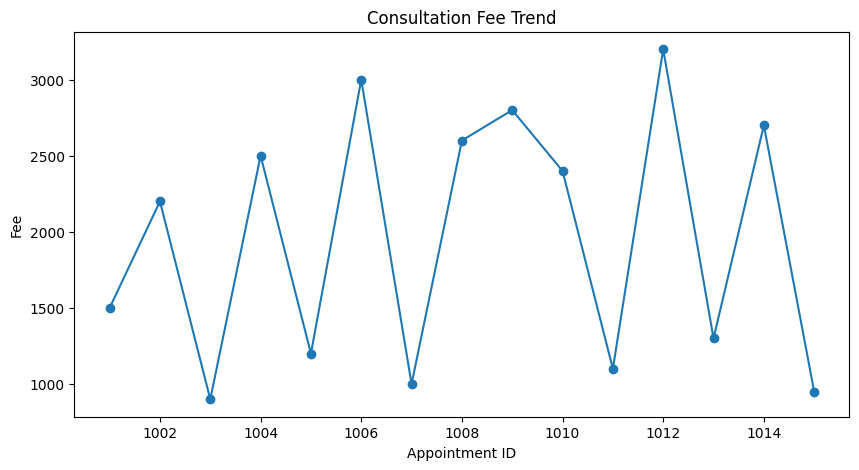

In [12]:
fee_trend = df.orderBy("appointment_id") \
    .select("appointment_id","consultation_fee") \
    .toPandas()

plt.figure(figsize=(10,5))
plt.plot(
    fee_trend["appointment_id"],
    fee_trend["consultation_fee"],
    marker="o"
)
plt.title("Consultation Fee Trend")
plt.xlabel("Appointment ID")
plt.ylabel("Fee")
plt.show()

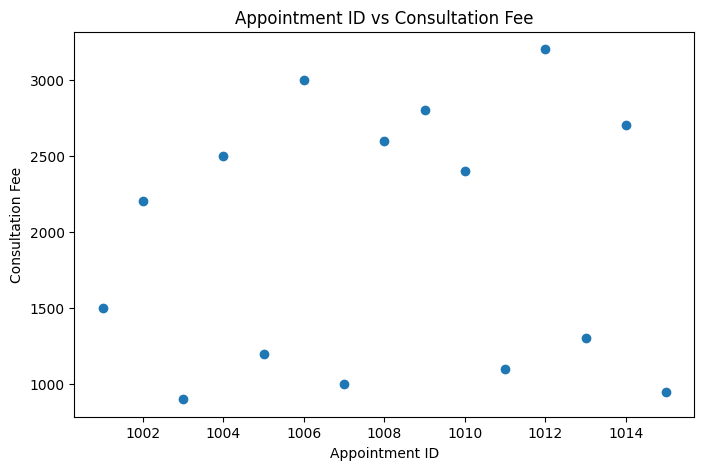

In [13]:
scatter_df = df.select(
    "appointment_id",
    "consultation_fee"
).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(
    scatter_df["appointment_id"],
    scatter_df["consultation_fee"]
)
plt.title("Appointment ID vs Consultation Fee")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

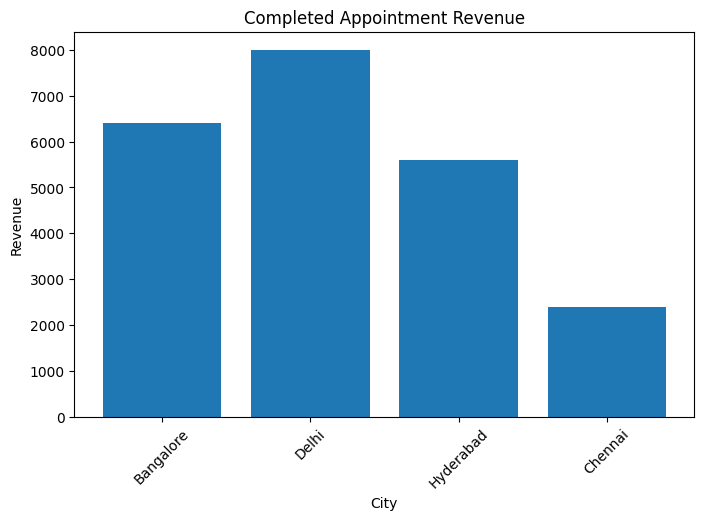

In [14]:
completed_df = df.filter(col("status")=="Completed")

completed_rev = completed_df.groupBy("city") \
    .agg(sum("consultation_fee").alias("revenue")) \
    .toPandas()

plt.figure(figsize=(8,5))
plt.bar(completed_rev["city"], completed_rev["revenue"])
plt.title("Completed Appointment Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

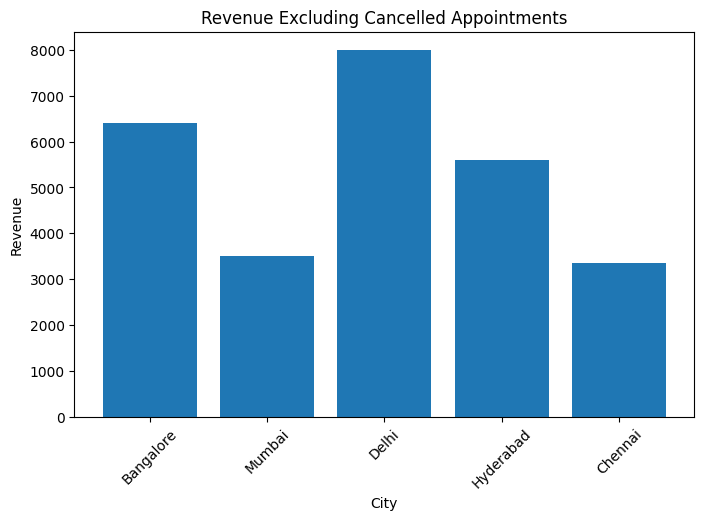

In [15]:
active_df = df.filter(col("status")!="Cancelled")

active_rev = active_df.groupBy("city") \
    .agg(sum("consultation_fee").alias("revenue")) \
    .toPandas()

plt.figure(figsize=(8,5))
plt.bar(active_rev["city"], active_rev["revenue"])
plt.title("Revenue Excluding Cancelled Appointments")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

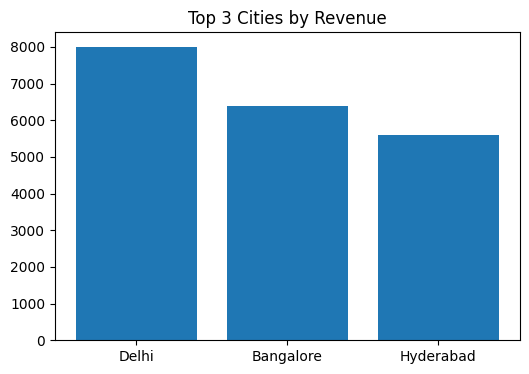

In [16]:
top3_cities = df.groupBy("city") \
    .agg(sum("consultation_fee").alias("revenue")) \
    .orderBy(desc("revenue")) \
    .limit(3) \
    .toPandas()

plt.figure(figsize=(6,4))
plt.bar(top3_cities["city"], top3_cities["revenue"])
plt.title("Top 3 Cities by Revenue")
plt.show()

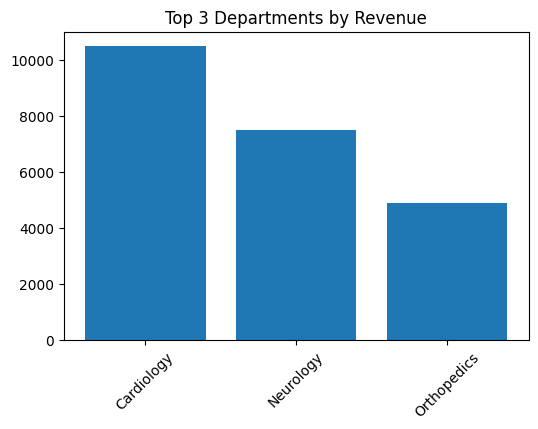

In [17]:
top3_dept = df.groupBy("department") \
    .agg(sum("consultation_fee").alias("revenue")) \
    .orderBy(desc("revenue")) \
    .limit(3) \
    .toPandas()

plt.figure(figsize=(6,4))
plt.bar(top3_dept["department"], top3_dept["revenue"])
plt.title("Top 3 Departments by Revenue")
plt.xticks(rotation=45)
plt.show()

In [18]:
lowest_hospital = df.groupBy("hospital") \
    .agg(sum("consultation_fee").alias("revenue")) \
    .orderBy("revenue") \
    .limit(1)

lowest_hospital.show()

+--------+-------+
|hospital|revenue|
+--------+-------+
| Yashoda|   6300|
+--------+-------+



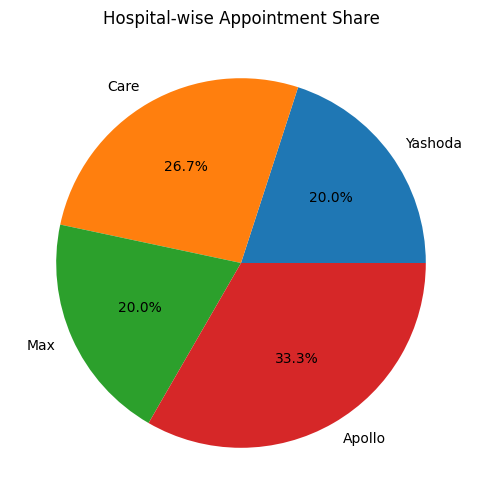

In [19]:
hospital_share = df.groupBy("hospital") \
    .count() \
    .toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    hospital_share["count"],
    labels=hospital_share["hospital"],
    autopct="%1.1f%%"
)
plt.title("Hospital-wise Appointment Share")
plt.show()

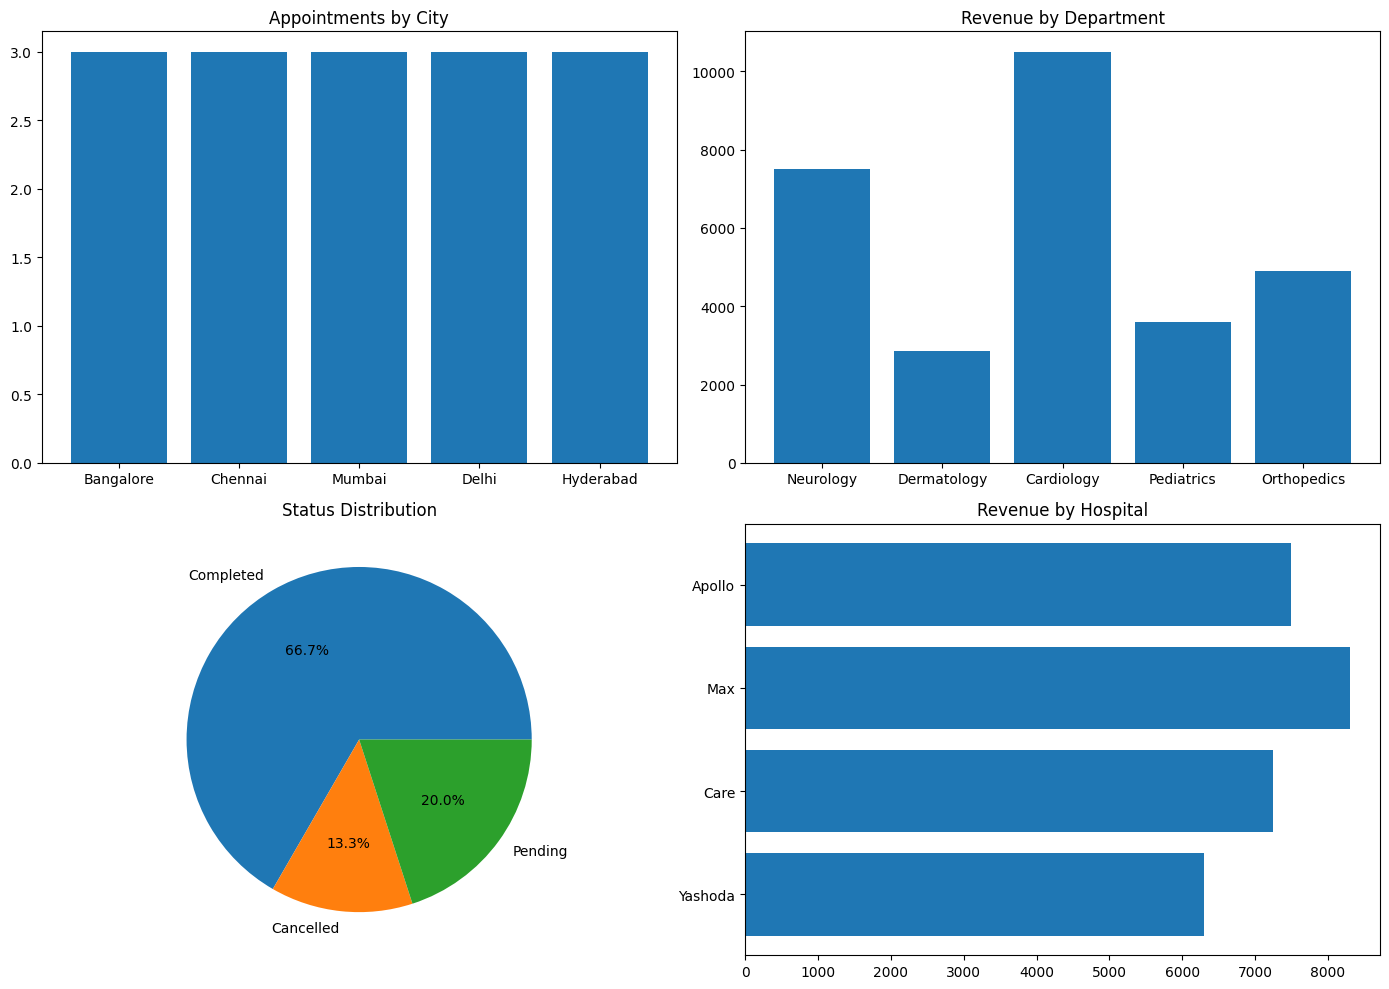

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# City Count
city_count = df.groupBy("city").count().toPandas()
axes[0,0].bar(city_count["city"], city_count["count"])
axes[0,0].set_title("Appointments by City")

# Revenue by Department
dept_rev = df.groupBy("department") \
    .agg(sum("consultation_fee").alias("revenue")) \
    .toPandas()
axes[0,1].bar(dept_rev["department"], dept_rev["revenue"])
axes[0,1].set_title("Revenue by Department")

# Status Distribution
status_count = df.groupBy("status").count().toPandas()
axes[1,0].pie(
    status_count["count"],
    labels=status_count["status"],
    autopct="%1.1f%%"
)
axes[1,0].set_title("Status Distribution")

# Revenue by Hospital
hospital_rev = df.groupBy("hospital") \
    .agg(sum("consultation_fee").alias("revenue")) \
    .toPandas()
axes[1,1].barh(
    hospital_rev["hospital"],
    hospital_rev["revenue"]
)
axes[1,1].set_title("Revenue by Hospital")

plt.tight_layout()
plt.show()